In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    '../../01_data_pipeline/datasets/enriched/unified_logs_enriched.csv',
    parse_dates=['timestamp']
)

df.head()
# Derived features
df['message_length'] = df['message'].str.len()
df['is_error'] = (df['type'] == 'Error').astype(int)
df['is_fault'] = (df['type'] == 'Fault').astype(int)

In [45]:
df.columns

Index(['timestamp', 'thread', 'type', 'activity', 'pid', 'ttl', 'raw_message',
       'process', 'subsystem', 'tags', 'message', 'hour', 'day_of_week',
       'is_weekend', 'off_hours', 'process_frequency', 'subsystem_frequency',
       'is_error', 'is_fault', 'is_system_process', 'rare_process',
       'first_seen_time', 'first_seen', 'session_id', 'first_seen_session',
       'count_last_hour', 'security_related', 'message_length'],
      dtype='object')

In [46]:
# How many unique values exist per feature?

df.nunique()

timestamp              12584
thread                   503
type                       4
activity                5145
pid                      128
ttl                        8
raw_message             3651
process                  118
subsystem                529
tags                    1076
message                 2871
hour                       1
day_of_week                1
is_weekend                 1
off_hours                  1
process_frequency         66
subsystem_frequency       73
is_error                   2
is_fault                   2
is_system_process          2
rare_process               2
first_seen_time          118
first_seen                 2
session_id                 1
first_seen_session         2
count_last_hour         1393
security_related           2
message_length           299
dtype: int64

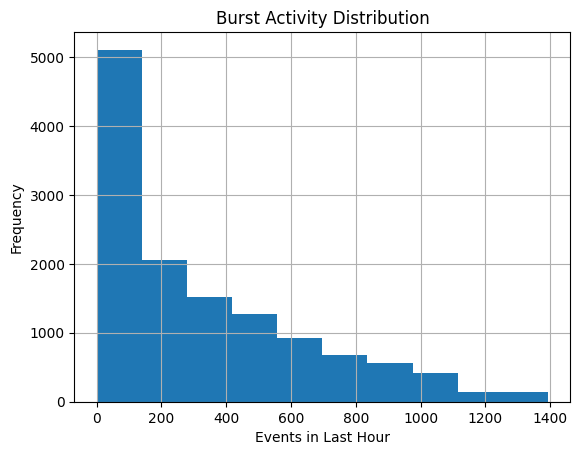

In [47]:
import matplotlib.pyplot as plt

df['count_last_hour'].hist()

plt.title('Burst Activity Distribution')
plt.xlabel('Events in Last Hour')
plt.ylabel('Frequency')
plt.show()


In [48]:
# Which features move together?

numeric_cols = [
    'pid',
    'ttl',
    'count_last_hour',
    'message_length',
    'is_error',
    'is_fault'
]

df[numeric_cols].corr()

,pid,ttl,count_last_hour,message_length,is_error,is_fault
pid,1.000000,-0.090175,-0.125342,0.062014,-0.009518,-0.006182
ttl,-0.090175,1.000000,-0.060997,0.083316,0.030097,0.087548
count_last_hour,-0.125342,-0.060997,1.000000,-0.157066,-0.036111,-0.015373
message_length,0.062014,0.083316,-0.157066,1.000000,0.067267,-0.000448
is_error,-0.009518,0.030097,-0.036111,0.067267,1.000000,-0.001545
is_fault,-0.006182,0.087548,-0.015373,-0.000448,-0.001545,1.000000


Off-hours has no values given the original unified logs file is just a 1-min snippet.

In [49]:
df['type'].value_counts()

type
Default     7526
Activity    5141
Error        129
Fault          3
Name: count, dtype: int64

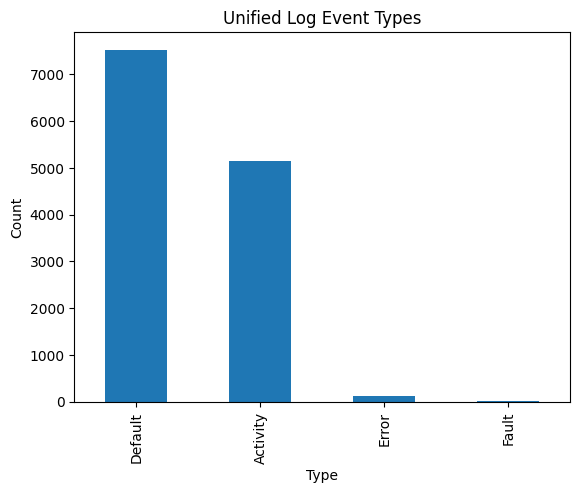

In [50]:
df['type'].value_counts().plot(kind='bar')

plt.title("Unified Log Event Types")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

In [51]:
df['process'].value_counts().head(15)

process
fseventsd                         1393
CoreServicesUIAgent               1112
CleanMyMac_5_MAS_Menu             1108
WindowServer                       979
runningboardd                      811
duetexpertd                        654
kernel                             620
bluetoothd                         617
BiomeAgent                         560
dasd                               442
CleanMyMac_5_MAS_HealthMonitor     333
airportd                           322
powerd                             313
AMPLibraryAgent                    260
mDNSResponder                      214
Name: count, dtype: int64

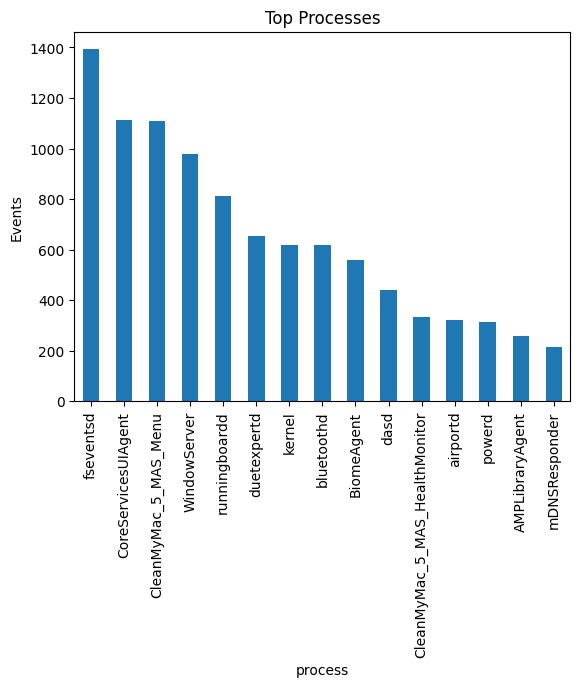

In [52]:
df['process'].value_counts().head(15).plot(kind='bar')

plt.title("Top Processes")
plt.ylabel("Events")
plt.show()

In [53]:
df['subsystem'].value_counts().head(15)

subsystem
[]                                           2770
['libsystem_info.dylib']                     1399
['CoreServicesInternal']                     1118
['CacheDelete']                               399
['CoreDuetContext']                           333
['BiomeFoundation']                           326
['RunningBoard', '501']                       294
['com.apple.DriverKit-AppleBCMWLAN.dext']     286
['SkyLight']                                  273
['HSTouchHIDService']                         246
['RunningBoard']                              232
['libxpc.dylib']                              212
['IntelligencePlatformCore']                  186
['Security']                                  184
['libxpc.dylib', '0xbad074640']               168
Name: count, dtype: int64

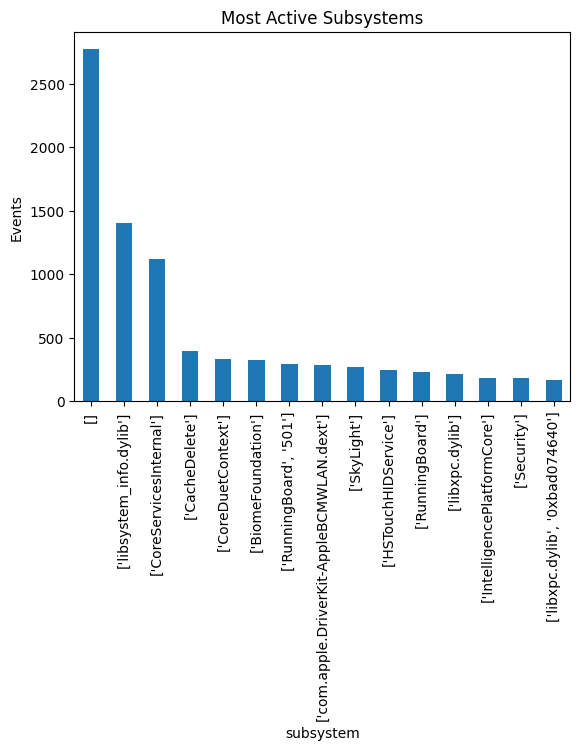

In [54]:
df['subsystem'].value_counts().head(15).plot(kind='bar')

plt.title("Most Active Subsystems")
plt.ylabel("Events")
plt.show()

In [55]:
df[df['is_error'] == 1][
    ['timestamp','process','message']
].head(20)

,timestamp,process,message
33,2026-06-22 19:00:21.699233+00:00,AMPLibraryAgent,AMSURLRequestDecoration: Skipping GUID parame...
35,2026-06-22 19:00:21.699339+00:00,AMPLibraryAgent,AMSURLRequestDecoration: Skipping add payment...
172,2026-06-22 19:00:22.131509+00:00,AMPLibraryAgent,AMSNetworkQualityInquiry: Missing entitlements...
182,2026-06-22 19:00:22.140933+00:00,AMPLibraryAgent,<ICURLBagProvider: 0x90cd98730> No matching re...
216,2026-06-22 19:00:43.241208+00:00,AMPLibraryAgent,"tcp_input flags= seq=2398487608, ack=0, win=0..."
224,2026-06-22 19:00:52.195560+00:00,AMPLibraryAgent,nw_read_request_report Receive failed with er...
225,2026-06-22 19:00:52.196274+00:00,AMPLibraryAgent,nw_read_request_report Receive failed with er...
228,2026-06-22 19:00:52.196352+00:00,AMPLibraryAgent,nw_read_request_report Receive failed with er...
247,2026-06-22 19:01:12.427218+00:00,AMPLibraryAgent,nw_read_request_report Receive failed with er...
248,2026-06-22 19:01:12.427228+00:00,AMPLibraryAgent,nw_read_request_report Receive failed with er...


In [ ]:
print(f"Number of Error events: {df['is_error'].sum()}")
print(f"Number of Fault events: {df['is_fault'].sum()}")

In [56]:
df[df['security_related']==1][
    ['timestamp','process','subsystem','message']
].head(20)

,timestamp,process,subsystem,message
86,2026-06-22 19:00:21.737663+00:00,AMPLibraryAgent,['Security'],SecKeyCopyPublicBytes
89,2026-06-22 19:00:21.738177+00:00,AMPLibraryAgent,"['Security', 'Trust 0x90cd3db00']","No pending evals, starting"
90,2026-06-22 19:00:21.738255+00:00,AMPLibraryAgent,['Security'],SecTrustEvaluateIfNecessaryFastAsync
91,2026-06-22 19:00:21.738370+00:00,AMPLibraryAgent,"['Security', 'Trust 0x90cd3db00']",Completed async eval kickoff
92,2026-06-22 19:00:21.753574+00:00,AMPLibraryAgent,"['Security', 'Trust 0x90cd3db00']",trustd returned 4
101,2026-06-22 19:00:21.753763+00:00,AMPLibraryAgent,['Security'],SecKeyCopyPublicBytes
102,2026-06-22 19:00:21.753835+00:00,AMPLibraryAgent,['Security'],SecKeyCopyPublicBytes
107,2026-06-22 19:00:21.754067+00:00,AMPLibraryAgent,['Security'],SecKeyCopyPublicBytes
109,2026-06-22 19:00:21.754148+00:00,AMPLibraryAgent,['Security'],SecTrustReportNetworkingAnalytics
114,2026-06-22 19:00:21.754417+00:00,AMPLibraryAgent,['Security'],SecTrustReportNetworkingAnalytics


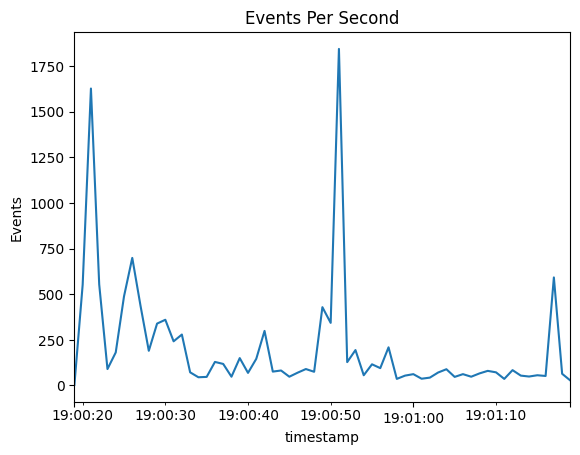

In [57]:
events_per_second = (
    df.set_index('timestamp')
      .resample('1s')
      .size()
)

events_per_second.plot()

plt.title("Events Per Second")
plt.ylabel("Events")
plt.show()

In [58]:
df['process'].nunique()

118

In [59]:
print(
    f"Unique processes observed: {df['process'].nunique()}"
)

Unique processes observed: 118


In [60]:
df['pid'].value_counts().head(10)

pid
347      1393
610      1112
932      1108
418       979
428       811
5897      654
0         620
75286     617
94113     560
396       442
Name: count, dtype: int64

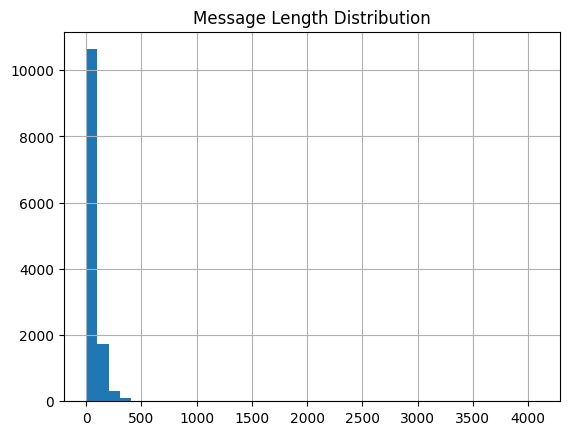

In [62]:
df['message_length'].hist(bins=40)

plt.title("Message Length Distribution")
plt.show()

In [ ]:
events_per_second = (
    df.set_index('timestamp')
      .resample('1s')
      .size()
)

events_per_second.plot()

plt.title("Events Per Second")
plt.ylabel("Events")
plt.show()